## Estudio con Cross-Validation (5-Fold)


> Tiempo estimado: 2~3 horas  con A100.

### Hipótesis
Las clases minoritarias (df, vasc, mel) se benefician de augmentation agresiva, mientras que las clases grandes (nv) no la necesitan. ¿Una estrategia de augmentation diferenciada por clase supera a una uniforme?

### Comparación
1. **Suave** (uniforme) — Mejor estrategia uniforme según estudio previo
2. **Por clase** — Intensidad proporcional al desbalanceo: mínima para nv, suave para clases medianas, agresiva para minoritarias

In [1]:
# ============================================
# CONFIGURACIÓN + IMPORTS
# ============================================
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/HAM10000'

import os, shutil, time, copy, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as Func
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    accuracy_score, roc_auc_score, precision_score, recall_score
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import StratifiedKFold

SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memoria: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Mounted at /content/drive
Dispositivo: cuda
GPU: NVIDIA A100-SXM4-40GB
Memoria: 42.4 GB


In [2]:
# ============================================
# COPIAR IMÁGENES A DISCO LOCAL
# ============================================
LOCAL_PATH = '/content/HAM10000'
os.makedirs(LOCAL_PATH, exist_ok=True)

if not os.path.exists(f'{LOCAL_PATH}/images_done.flag'):
    for folder in ['HAM10000_images_part_1', 'HAM10000_images_part_2']:
        shutil.copytree(f'{BASE_PATH}/{folder}', f'{LOCAL_PATH}/{folder}')
    shutil.copy(f'{BASE_PATH}/ham10000_metadata_clean.csv', f'{LOCAL_PATH}/')
    open(f'{LOCAL_PATH}/images_done.flag', 'w').close()
    print('Imágenes copiadas.')
else:
    print('Ya copiadas.')

METADATA_PATH = f'{LOCAL_PATH}/ham10000_metadata_clean.csv'

Imágenes copiadas.


In [3]:
# ============================================
# CARGAR DATOS + CONSTANTES
# ============================================
df = pd.read_csv(METADATA_PATH)
df['image_path'] = df['image_path'].str.replace('/content/drive/MyDrive/HAM10000', LOCAL_PATH)

lesion_df = df.groupby('lesion_id').first().reset_index()
print(f'Dataset: {len(df)} imágenes, {len(lesion_df)} lesiones únicas, {df["dx"].nunique()} clases')

IMG_SIZE = 224
NUM_CLASSES = 7
BATCH_SIZE = 64
K_FOLDS = 5

CLASS_NAMES = {
    'nv': 'Melanocytic nevi', 'mel': 'Melanoma',
    'bkl': 'Benign keratosis', 'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses', 'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}
class_to_idx = {cls: i for i, cls in enumerate(sorted(CLASS_NAMES.keys()))}
idx_to_class = {i: cls for cls, i in class_to_idx.items()}
class_names_sorted = sorted(CLASS_NAMES.keys())

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print(f'\nDistribución de clases:')
for cls in class_names_sorted:
    n = len(df[df['dx'] == cls])
    print(f'  {cls:6s} ({CLASS_NAMES[cls]:25s}): {n:5d}')

Dataset: 10015 imágenes, 7470 lesiones únicas, 7 clases

Distribución de clases:
  akiec  (Actinic keratoses        ):   327
  bcc    (Basal cell carcinoma     ):   514
  bkl    (Benign keratosis         ):  1099
  df     (Dermatofibroma           ):   115
  mel    (Melanoma                 ):  1113
  nv     (Melanocytic nevi         ):  6705
  vasc   (Vascular lesions         ):   142


In [4]:
# ============================================
# DATASETS
# ============================================
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        label = class_to_idx[row['dx']]
        if self.transform:
            img = self.transform(img)
        return img, label

class HAM10000DatasetPerClass(Dataset):
    def __init__(self, dataframe, transforms_per_class):
        self.df = dataframe.reset_index(drop=True)
        self.transforms_per_class = transforms_per_class
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        label = class_to_idx[row['dx']]
        transform = self.transforms_per_class[row['dx']]
        img = transform(img)
        return img, label

print('Datasets definidos.')

Datasets definidos.


In [5]:
# ============================================
# TRANSFORMS
# ============================================
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

aug_minima = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

aug_suave = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

aug_agresiva = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=90),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15), scale=(0.8, 1.2)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15))
])

# Estrategia por clase: intensidad proporcional al desbalanceo
transforms_por_clase = {
    'nv':    aug_minima,     # 6705 muestras -> no necesita augmentation
    'mel':   aug_agresiva,   # 1113 -> necesita variedad
    'bkl':   aug_suave,      # 1099 -> moderada
    'bcc':   aug_suave,      #  514 -> moderada
    'akiec': aug_suave,      #  327 -> moderada
    'vasc':  aug_agresiva,   #  142 -> muy pocas, agresiva
    'df':    aug_agresiva    #  115 -> muy pocas, agresiva
}

augmentation_levels = ['suave', 'por_clase']

print('2 estrategias de augmentation:')
print('  1. Suave (uniforme): misma transform para todas las clases')
print('  2. Por clase: augmentation proporcional al desbalanceo')
print(f'\nAsignación por clase:')
for cls in class_names_sorted:
    nivel = 'minima' if transforms_por_clase[cls] is aug_minima else ('suave' if transforms_por_clase[cls] is aug_suave else 'agresiva')
    n = len(df[df['dx'] == cls])
    print(f'  {cls:6s} ({n:5d} muestras) -> {nivel}')

2 estrategias de augmentation:
  1. Suave (uniforme): misma transform para todas las clases
  2. Por clase: augmentation proporcional al desbalanceo

Asignación por clase:
  akiec  (  327 muestras) -> suave
  bcc    (  514 muestras) -> suave
  bkl    ( 1099 muestras) -> suave
  df     (  115 muestras) -> agresiva
  mel    ( 1113 muestras) -> agresiva
  nv     ( 6705 muestras) -> minima
  vasc   (  142 muestras) -> agresiva


In [6]:
# ============================================
# FUNCIONES
# ============================================
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                num_epochs=30, patience=7):
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total_samples = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        model.eval()
        running_loss_v, correct_v, total_v = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_loss_v += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                correct_v += (preds == labels).sum().item()
                total_v += labels.size(0)
        val_loss = running_loss_v / total_v

        if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_loss)
        elif scheduler:
            scheduler.step()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    model.load_state_dict(best_model_wts)
    return model


def evaluate_model(model, test_loader):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

print('Funciones definidas.')

Funciones definidas.


In [7]:
# ============================================
# ENTRENAR RESNET-50 EN UN FOLD
# ============================================
def train_resnet50_fold(df_train, df_test, aug_name):
    if aug_name == 'por_clase':
        train_dataset = HAM10000DatasetPerClass(df_train, transforms_por_clase)
    else:
        train_dataset = HAM10000Dataset(df_train, transform=aug_suave)
    test_dataset = HAM10000Dataset(df_test, transform=val_test_transforms)

    train_labels = [class_to_idx[dx] for dx in df_train['dx']]
    class_counts = Counter(train_labels)
    total = sum(class_counts.values())
    weights = {cls: total / count for cls, count in class_counts.items()}
    sample_weights = [weights[label] for label in train_labels]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                              num_workers=8, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=8, pin_memory=True)

    # FASE 1: Feature Extraction
    resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    for param in resnet.parameters():
        param.requires_grad = False
    num_ftrs = resnet.fc.in_features
    resnet.fc = nn.Sequential(
        nn.Dropout(0.3), nn.Linear(num_ftrs, 512),
        nn.ReLU(), nn.Dropout(0.2), nn.Linear(512, NUM_CLASSES)
    )
    resnet = resnet.to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.Adam(resnet.fc.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

    resnet = train_model(resnet, train_loader, test_loader, criterion, optimizer, scheduler,
                         num_epochs=15, patience=5)

    # FASE 2: Fine-Tuning
    for param in resnet.layer3.parameters():
        param.requires_grad = True
    for param in resnet.layer4.parameters():
        param.requires_grad = True

    optimizer = optim.Adam([
        {'params': resnet.layer3.parameters(), 'lr': 5e-6},
        {'params': resnet.layer4.parameters(), 'lr': 1e-5},
        {'params': resnet.fc.parameters(), 'lr': 1e-4}
    ])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25, eta_min=1e-7)

    resnet = train_model(resnet, train_loader, test_loader, criterion, optimizer, scheduler,
                         num_epochs=30, patience=7)

    labels, preds, probs = evaluate_model(resnet, test_loader)
    acc = accuracy_score(labels, preds)

    del resnet
    torch.cuda.empty_cache()

    return labels, preds, probs, acc

print('Función train_resnet50_fold definida.')

Función train_resnet50_fold definida.


In [8]:
# ============================================
# CREAR FOLDS ESTRATIFICADOS POR LESIÓN
# ============================================
lesion_ids = lesion_df['lesion_id'].values
lesion_labels = lesion_df['dx'].values

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

folds = []
for train_lesion_idx, test_lesion_idx in skf.split(lesion_ids, lesion_labels):
    train_lesions = set(lesion_ids[train_lesion_idx])
    test_lesions = set(lesion_ids[test_lesion_idx])
    df_train = df[df['lesion_id'].isin(train_lesions)].copy()
    df_test = df[df['lesion_id'].isin(test_lesions)].copy()
    folds.append((df_train, df_test))

print(f'{K_FOLDS} folds creados (estratificados por lesión):')
for i, (df_tr, df_te) in enumerate(folds):
    print(f'  Fold {i+1}: Train={len(df_tr)}, Test={len(df_te)}')

5 folds creados (estratificados por lesión):
  Fold 1: Train=8018, Test=1997
  Fold 2: Train=7987, Test=2028
  Fold 3: Train=8040, Test=1975
  Fold 4: Train=7994, Test=2021
  Fold 5: Train=8021, Test=1994


---
## 5. Ejecutar (2 estrategias × 5 folds = 10 entrenamientos)

Tiempo estimado: ~3-4 horas con A100

In [9]:
# ============================================
# EJECUTAR: 2 estrategias x 5 folds
# ============================================
all_results = {}
total_start = time.time()

for aug_name in augmentation_levels:
    print(f'\n{"#"*60}')
    print(f'###  ESTRATEGIA: {aug_name.upper()}')
    print(f'{"#"*60}')

    aug_start = time.time()
    all_labels, all_preds, all_probs = [], [], []
    fold_accs = []

    for fold_idx, (df_train, df_test) in enumerate(folds):
        fold_start = time.time()
        print(f'\n  Fold {fold_idx+1}/{K_FOLDS}...', end=' ')

        labels, preds, probs, acc = train_resnet50_fold(df_train, df_test, aug_name)

        all_labels.extend(labels)
        all_preds.extend(preds)
        all_probs.extend(probs)
        fold_accs.append(acc)

        fold_time = (time.time() - fold_start) / 60
        print(f'Acc: {acc:.4f} ({fold_time:.1f} min)')

    all_results[aug_name] = {
        'labels': np.array(all_labels),
        'preds': np.array(all_preds),
        'probs': np.array(all_probs),
        'fold_accs': fold_accs
    }

    aug_time = (time.time() - aug_start) / 60
    print(f'\n>>> {aug_name.upper()}: {np.mean(fold_accs):.4f} \u00b1 {np.std(fold_accs):.4f} ({aug_time:.0f} min)')

    # Guardar parcial en Drive
    partial = {'preds': [int(p) for p in all_preds], 'labels': [int(l) for l in all_labels], 'fold_accs': fold_accs}
    with open(f'{BASE_PATH}/cv_results_{aug_name}.json', 'w') as f:
        json.dump(partial, f)
    print(f'    Guardado en Drive.')

total_time = (time.time() - total_start) / 60
print(f'\n{"="*60}')
print(f'  COMPLETADO en {total_time:.0f} min ({total_time/60:.1f} horas)')
print(f'{"="*60}')


############################################################
###  ESTRATEGIA: SUAVE
############################################################

  Fold 1/5... Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 99.2MB/s]


Acc: 0.7526 (16.9 min)

  Fold 2/5... Acc: 0.7840 (17.7 min)

  Fold 3/5... Acc: 0.7559 (15.6 min)

  Fold 4/5... Acc: 0.7526 (16.5 min)

  Fold 5/5... Acc: 0.7778 (17.6 min)

>>> SUAVE: 0.7646 ± 0.0135 (84 min)
    Guardado en Drive.

############################################################
###  ESTRATEGIA: POR_CLASE
############################################################

  Fold 1/5... Acc: 0.7211 (7.2 min)

  Fold 2/5... Acc: 0.7091 (7.1 min)

  Fold 3/5... Acc: 0.7327 (11.8 min)

  Fold 4/5... Acc: 0.7219 (7.6 min)

  Fold 5/5... Acc: 0.7312 (9.3 min)

>>> POR_CLASE: 0.7232 ± 0.0085 (43 min)
    Guardado en Drive.

  COMPLETADO en 127 min (2.1 horas)


---
## 6. Métricas

In [10]:
# ============================================
# MÉTRICAS AGREGADAS
# ============================================
metrics_cv = {}
target_names = [f'{idx_to_class[i]} ({CLASS_NAMES[idx_to_class[i]]})' for i in range(NUM_CLASSES)]

for aug_name in augmentation_levels:
    labels = all_results[aug_name]['labels']
    preds = all_results[aug_name]['preds']
    probs = all_results[aug_name]['probs']
    fold_accs = all_results[aug_name]['fold_accs']

    acc = accuracy_score(labels, preds)
    f1_w = f1_score(labels, preds, average='weighted')
    f1_m = f1_score(labels, preds, average='macro')
    prec_w = precision_score(labels, preds, average='weighted')
    rec_w = recall_score(labels, preds, average='weighted')

    labels_bin = label_binarize(labels, classes=list(range(NUM_CLASSES)))
    try:
        auc_val = roc_auc_score(labels_bin, probs, average='weighted', multi_class='ovr')
    except:
        auc_val = float('nan')

    report = classification_report(labels, preds, target_names=target_names, output_dict=True)
    class_report = {}
    for i in range(NUM_CLASSES):
        class_report[idx_to_class[i]] = report[target_names[i]]

    metrics_cv[aug_name] = {
        'accuracy': acc, 'accuracy_std': np.std(fold_accs),
        'f1_weighted': f1_w, 'f1_macro': f1_m,
        'precision_weighted': prec_w, 'recall_weighted': rec_w,
        'auc_roc': auc_val, 'class_report': class_report,
        'fold_accs': fold_accs
    }

    print(f'\n=== {aug_name.upper()} ===')
    print(f'Accuracy: {acc:.4f} \u00b1 {np.std(fold_accs):.4f}')
    print(f'F1w: {f1_w:.4f} | F1m: {f1_m:.4f} | AUC: {auc_val:.4f}')
    print(classification_report(labels, preds, target_names=target_names))


=== SUAVE ===
Accuracy: 0.7647 ± 0.0135
F1w: 0.7759 | F1m: 0.6229 | AUC: 0.9342
                            precision    recall  f1-score   support

 akiec (Actinic keratoses)       0.41      0.66      0.50       327
bcc (Basal cell carcinoma)       0.59      0.75      0.66       514
    bkl (Benign keratosis)       0.55      0.60      0.58      1099
       df (Dermatofibroma)       0.45      0.65      0.54       115
            mel (Melanoma)       0.47      0.54      0.50      1113
     nv (Melanocytic nevi)       0.93      0.84      0.88      6705
   vasc (Vascular lesions)       0.61      0.83      0.71       142

                  accuracy                           0.76     10015
                 macro avg       0.57      0.69      0.62     10015
              weighted avg       0.80      0.76      0.78     10015


=== POR_CLASE ===
Accuracy: 0.7231 ± 0.0085
F1w: 0.6481 | F1m: 0.4191 | AUC: 0.8590
                            precision    recall  f1-score   support

 akiec (Actini

---
## 7. Tablas comparativas

In [11]:
# ============================================
# TABLA GLOBAL
# ============================================
AUG_LABELS = {'suave': 'Suave (uniforme)', 'por_clase': 'Por clase'}

rows = []
for aug_name in augmentation_levels:
    m = metrics_cv[aug_name]
    rows.append({
        'Estrategia': AUG_LABELS[aug_name],
        'Accuracy': f"{m['accuracy']:.4f} \u00b1 {m['accuracy_std']:.4f}",
        'F1 Weighted': f"{m['f1_weighted']:.4f}",
        'F1 Macro': f"{m['f1_macro']:.4f}",
        'Precision (w)': f"{m['precision_weighted']:.4f}",
        'Recall (w)': f"{m['recall_weighted']:.4f}",
        'AUC-ROC': f"{m['auc_roc']:.4f}"
    })
print('\n=== COMPARACIÓN GLOBAL (5-Fold CV) ===')
display(pd.DataFrame(rows))


=== COMPARACIÓN GLOBAL (5-Fold CV) ===


,Estrategia,Accuracy,F1 Weighted,F1 Macro,Precision (w),Recall (w),AUC-ROC
0,Suave (uniforme),0.7647 ± 0.0135,0.7759,0.6229,0.7954,0.7647,0.9342
1,Por clase,0.7231 ± 0.0085,0.6481,0.4191,0.6722,0.7231,0.8590


In [12]:
# ============================================
# TABLAS POR CLASE
# ============================================
for metric_name in ['precision', 'recall', 'f1-score']:
    print(f'\n=== {metric_name.upper()} POR CLASE (5-Fold CV) ===')
    rows = []
    for cls in class_names_sorted:
        row = {'Clase': f'{cls} ({CLASS_NAMES[cls]})'}
        for aug_name in augmentation_levels:
            report = metrics_cv[aug_name]['class_report']
            row[AUG_LABELS[aug_name]] = f"{report[cls][metric_name]:.3f}"
        # Diferencia
        diff = metrics_cv['por_clase']['class_report'][cls][metric_name] - metrics_cv['suave']['class_report'][cls][metric_name]
        row['Diferencia'] = f"{diff:+.3f}"
        rows.append(row)
    display(pd.DataFrame(rows))


=== PRECISION POR CLASE (5-Fold CV) ===


,Clase,Suave (uniforme),Por clase,Diferencia
0,akiec (Actinic keratoses),0.405,0.409,+0.004
1,bcc (Basal cell carcinoma),0.587,0.657,+0.070
2,bkl (Benign keratosis),0.555,0.736,+0.181
3,df (Dermatofibroma),0.455,0.680,+0.225
4,mel (Melanoma),0.468,0.292,-0.176
5,nv (Melanocytic nevi),0.934,0.736,-0.198
6,vasc (Vascular lesions),0.615,0.804,+0.190



=== RECALL POR CLASE (5-Fold CV) ===


,Clase,Suave (uniforme),Por clase,Diferencia
0,akiec (Actinic keratoses),0.661,0.379,-0.281
1,bcc (Basal cell carcinoma),0.747,0.399,-0.348
2,bkl (Benign keratosis),0.599,0.183,-0.416
3,df (Dermatofibroma),0.652,0.148,-0.504
4,mel (Melanoma),0.537,0.006,-0.531
5,nv (Melanocytic nevi),0.837,0.986,+0.149
6,vasc (Vascular lesions),0.831,0.549,-0.282



=== F1-SCORE POR CLASE (5-Fold CV) ===


,Clase,Suave (uniforme),Por clase,Diferencia
0,akiec (Actinic keratoses),0.502,0.394,-0.109
1,bcc (Basal cell carcinoma),0.658,0.496,-0.161
2,bkl (Benign keratosis),0.576,0.293,-0.283
3,df (Dermatofibroma),0.536,0.243,-0.293
4,mel (Melanoma),0.500,0.012,-0.488
5,nv (Melanocytic nevi),0.883,0.843,-0.040
6,vasc (Vascular lesions),0.707,0.653,-0.054


---
## 8. Gráficos

In [13]:
AUG_COLORS = {'suave': '#4CAF50', 'por_clase': '#FF9800'}
NAVY = '#1a1a2e'

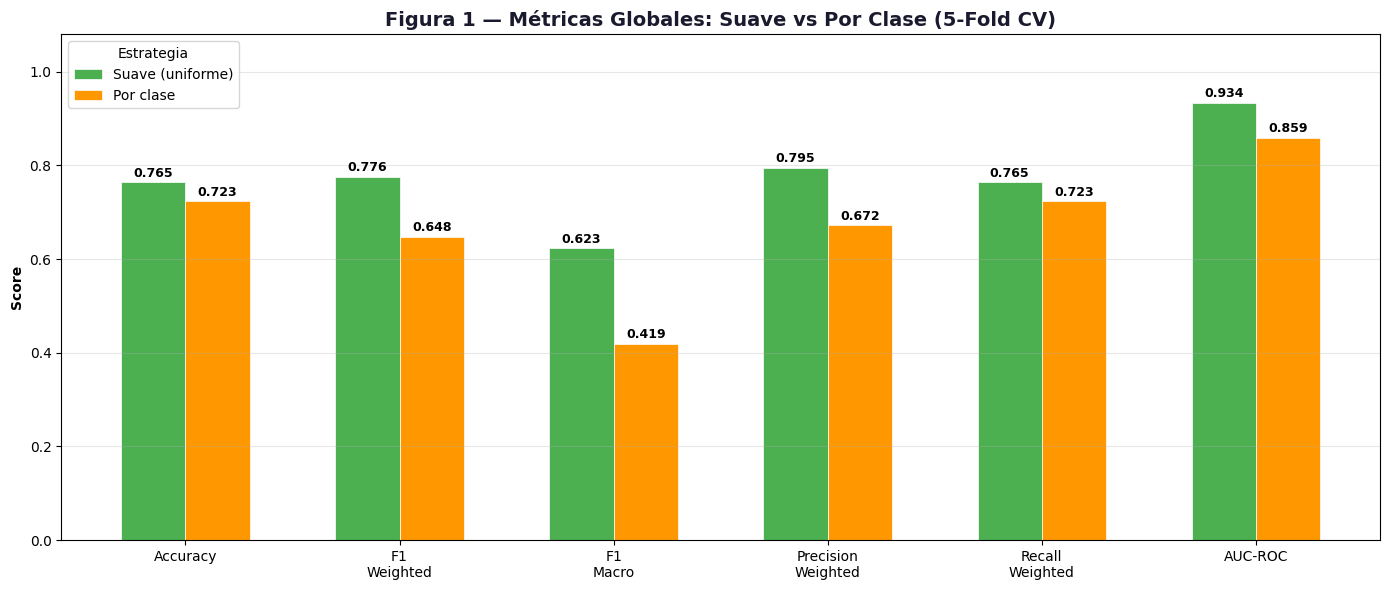

In [14]:
# ============================================
# FIGURA 1: MÉTRICAS GLOBALES
# ============================================
metrics_to_plot = ['accuracy', 'f1_weighted', 'f1_macro', 'precision_weighted', 'recall_weighted', 'auc_roc']
metric_labels = ['Accuracy', 'F1\nWeighted', 'F1\nMacro', 'Precision\nWeighted', 'Recall\nWeighted', 'AUC-ROC']

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(metrics_to_plot))
width = 0.3

for i, aug_name in enumerate(augmentation_levels):
    values = [metrics_cv[aug_name][m] for m in metrics_to_plot]
    bars = ax.bar(x + i*width, values, width, label=AUG_LABELS[aug_name],
                  color=AUG_COLORS[aug_name], edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Score', fontweight='bold')
ax.set_xticks(x + width/2)
ax.set_xticklabels(metric_labels)
ax.legend(title='Estrategia')
ax.set_ylim(0, 1.08)
ax.grid(axis='y', alpha=0.3)
ax.set_title('Figura 1 \u2014 Métricas Globales: Suave vs Por Clase (5-Fold CV)',
             fontweight='bold', color=NAVY, fontsize=14)
plt.tight_layout()
plt.show()

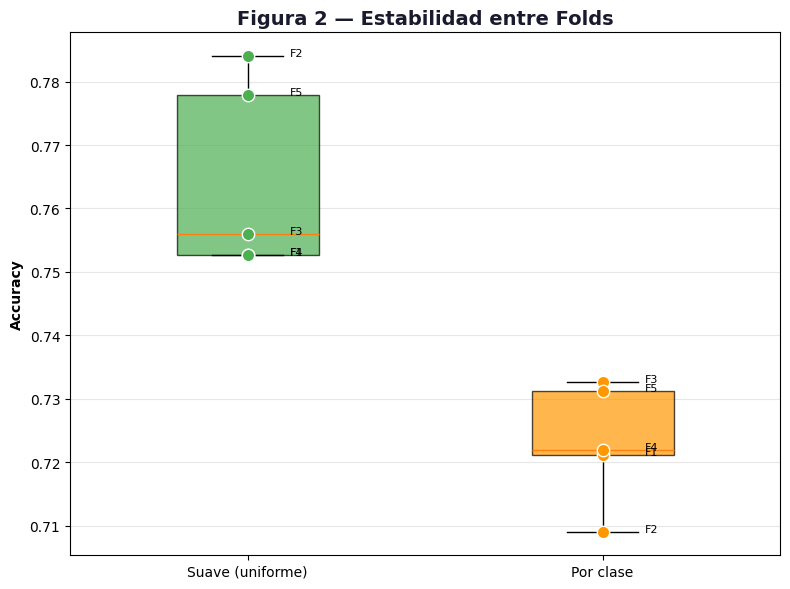

In [15]:
# ============================================
# FIGURA 2: BOXPLOT ACCURACY POR FOLD
# ============================================
fig, ax = plt.subplots(figsize=(8, 6))
data_box = [all_results[aug]['fold_accs'] for aug in augmentation_levels]
bp = ax.boxplot(data_box, labels=[AUG_LABELS[a] for a in augmentation_levels],
                patch_artist=True, widths=0.4)

for patch, aug_name in zip(bp['boxes'], augmentation_levels):
    patch.set_facecolor(AUG_COLORS[aug_name])
    patch.set_alpha(0.7)

for i, aug_name in enumerate(augmentation_levels):
    accs = all_results[aug_name]['fold_accs']
    ax.scatter([i+1]*len(accs), accs, color=AUG_COLORS[aug_name], s=80, zorder=3, edgecolor='white')
    for j, acc in enumerate(accs):
        ax.annotate(f'F{j+1}', (i+1.12, acc), fontsize=8)

ax.set_ylabel('Accuracy', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_title('Figura 2 \u2014 Estabilidad entre Folds',
             fontweight='bold', color=NAVY, fontsize=14)
plt.tight_layout()
plt.show()

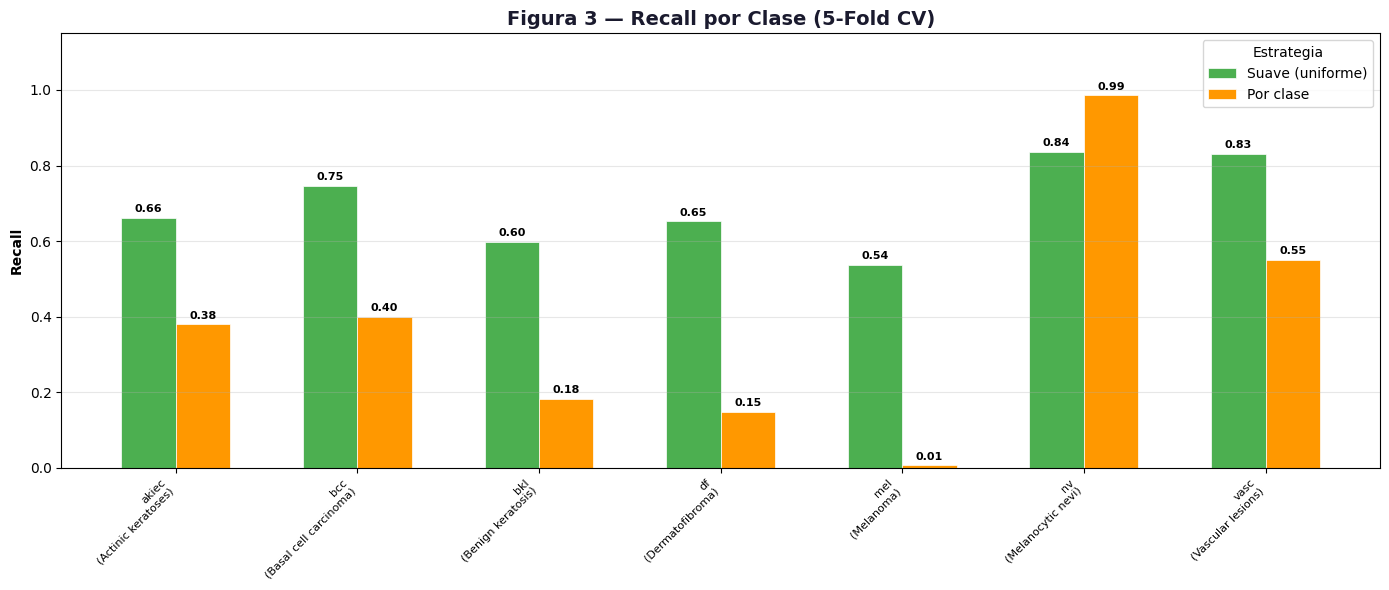

In [16]:
# ============================================
# FIGURA 3: RECALL POR CLASE
# ============================================
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(class_names_sorted))
width = 0.3

for i, aug_name in enumerate(augmentation_levels):
    report = metrics_cv[aug_name]['class_report']
    values = [report[cls]['recall'] for cls in class_names_sorted]
    bars = ax.bar(x + i*width, values, width, label=AUG_LABELS[aug_name],
                  color=AUG_COLORS[aug_name], edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_ylabel('Recall', fontweight='bold')
ax.set_xticks(x + width/2)
ax.set_xticklabels([f'{c}\n({CLASS_NAMES[c]})' for c in class_names_sorted], fontsize=8, rotation=45, ha='right')
ax.legend(title='Estrategia')
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)
ax.set_title('Figura 3 \u2014 Recall por Clase (5-Fold CV)',
             fontweight='bold', color=NAVY, fontsize=14)
plt.tight_layout()
plt.show()

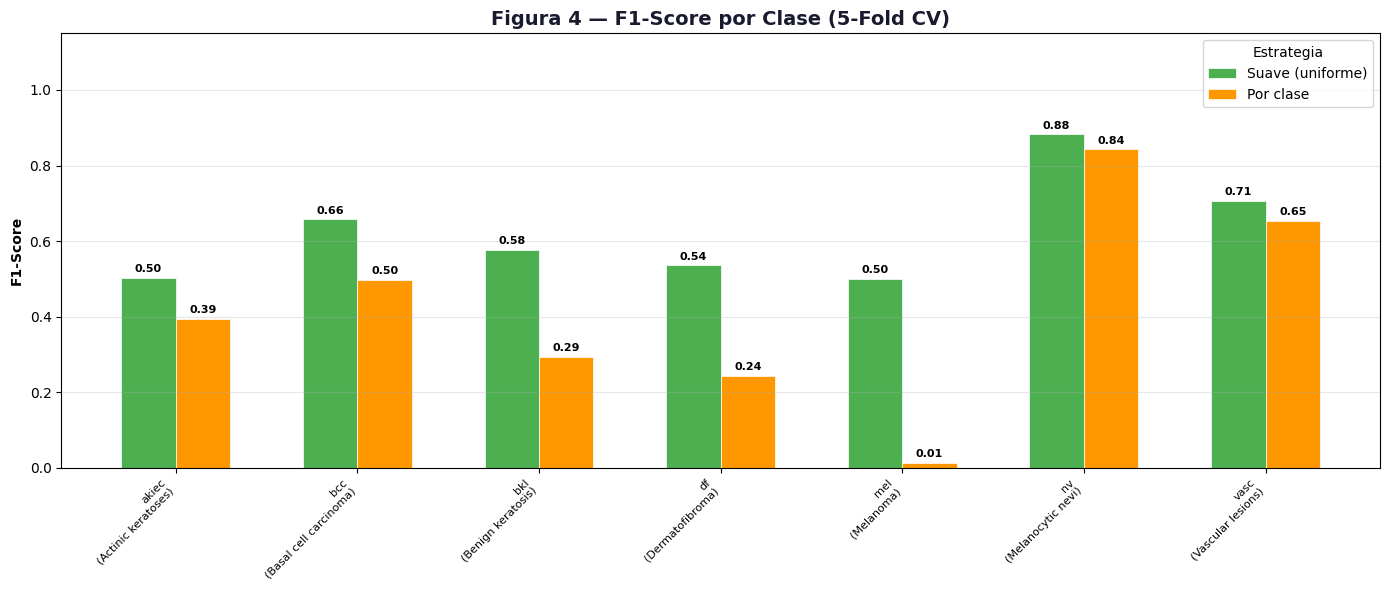

In [17]:
# ============================================
# FIGURA 4: F1-SCORE POR CLASE
# ============================================
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(class_names_sorted))
width = 0.3

for i, aug_name in enumerate(augmentation_levels):
    report = metrics_cv[aug_name]['class_report']
    values = [report[cls]['f1-score'] for cls in class_names_sorted]
    bars = ax.bar(x + i*width, values, width, label=AUG_LABELS[aug_name],
                  color=AUG_COLORS[aug_name], edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_ylabel('F1-Score', fontweight='bold')
ax.set_xticks(x + width/2)
ax.set_xticklabels([f'{c}\n({CLASS_NAMES[c]})' for c in class_names_sorted], fontsize=8, rotation=45, ha='right')
ax.legend(title='Estrategia')
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)
ax.set_title('Figura 4 \u2014 F1-Score por Clase (5-Fold CV)',
             fontweight='bold', color=NAVY, fontsize=14)
plt.tight_layout()
plt.show()

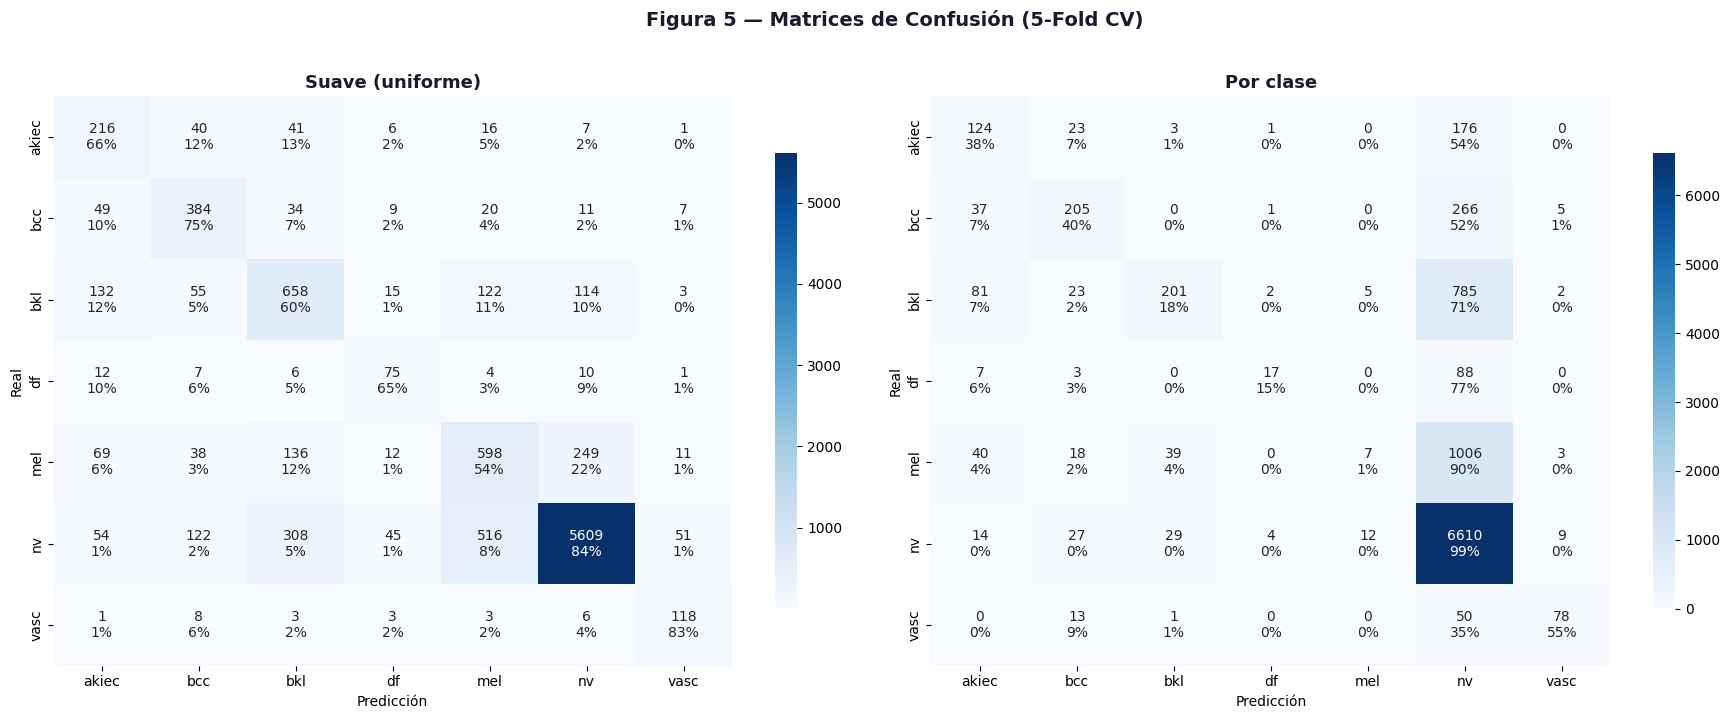

In [18]:
# ============================================
# FIGURA 5: MATRICES DE CONFUSIÓN
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, aug_name in zip(axes, augmentation_levels):
    labels = all_results[aug_name]['labels']
    preds = all_results[aug_name]['preds']
    cm = confusion_matrix(labels, preds)
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    annot = np.array([[f'{count}\n{pct:.0f}%' for count, pct in zip(row_c, row_p)]
                      for row_c, row_p in zip(cm, cm_pct)])
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
                xticklabels=class_names_sorted, yticklabels=class_names_sorted,
                ax=ax, cbar_kws={'shrink': 0.8})
    ax.set_title(f'{AUG_LABELS[aug_name]}', fontweight='bold', color=NAVY, fontsize=13)
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicción')

fig.suptitle('Figura 5 \u2014 Matrices de Confusión (5-Fold CV)',
             fontsize=14, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.show()

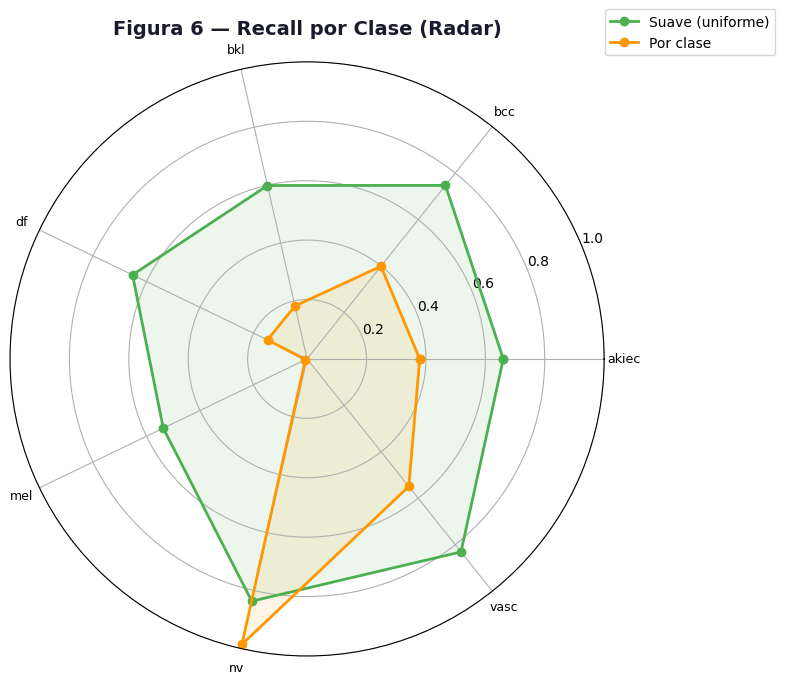

In [19]:
# ============================================
# FIGURA 6: RADAR CHART
# ============================================
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

angles = np.linspace(0, 2 * np.pi, len(class_names_sorted), endpoint=False).tolist()
angles += angles[:1]

for aug_name in augmentation_levels:
    report = metrics_cv[aug_name]['class_report']
    values = [report[cls]['recall'] for cls in class_names_sorted]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=AUG_LABELS[aug_name],
            color=AUG_COLORS[aug_name])
    ax.fill(angles, values, alpha=0.1, color=AUG_COLORS[aug_name])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(class_names_sorted, fontsize=9)
ax.set_ylim(0, 1)
ax.set_title('Figura 6 \u2014 Recall por Clase (Radar)',
             fontweight='bold', color=NAVY, fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

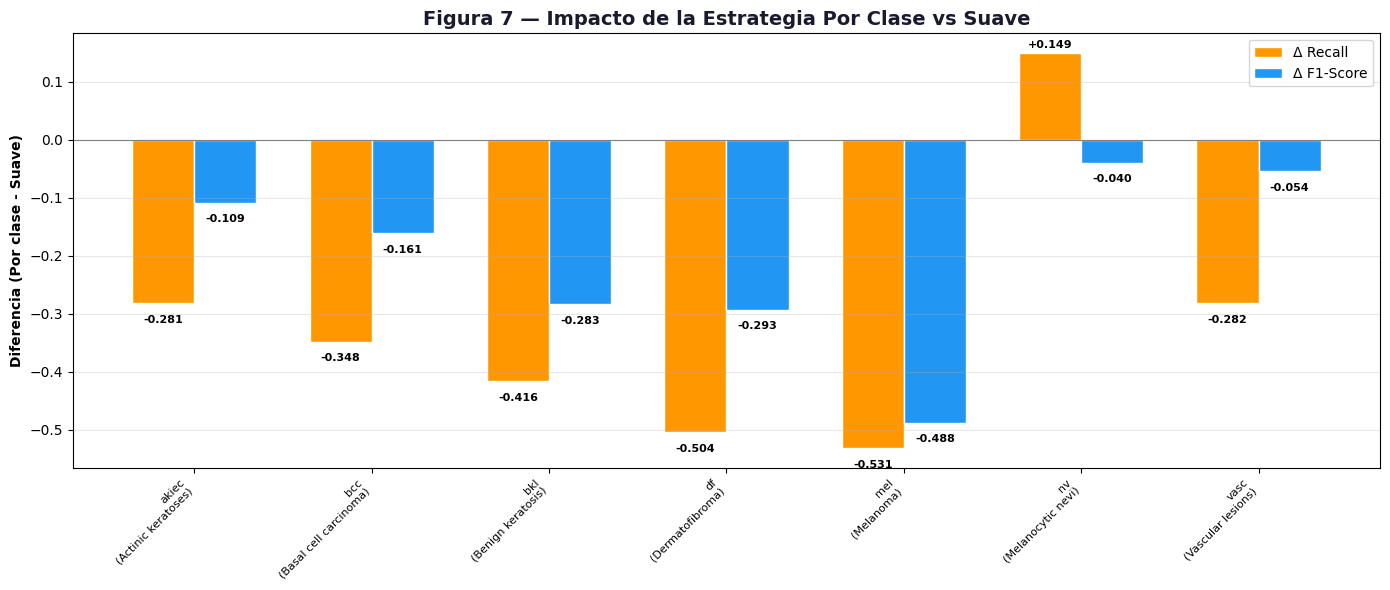

In [20]:
# ============================================
# FIGURA 7: DIFERENCIA POR CLASE (Por clase - Suave)
# ============================================
fig, ax = plt.subplots(figsize=(14, 6))

diffs_recall = []
diffs_f1 = []
for cls in class_names_sorted:
    r_pc = metrics_cv['por_clase']['class_report'][cls]['recall']
    r_su = metrics_cv['suave']['class_report'][cls]['recall']
    diffs_recall.append(r_pc - r_su)
    f_pc = metrics_cv['por_clase']['class_report'][cls]['f1-score']
    f_su = metrics_cv['suave']['class_report'][cls]['f1-score']
    diffs_f1.append(f_pc - f_su)

x = np.arange(len(class_names_sorted))
width = 0.35

bars1 = ax.bar(x - width/2, diffs_recall, width, label='\u0394 Recall', color='#FF9800', edgecolor='white')
bars2 = ax.bar(x + width/2, diffs_f1, width, label='\u0394 F1-Score', color='#2196F3', edgecolor='white')

for bar, val in zip(bars1, diffs_recall):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.005 if val >= 0 else -0.02),
            f'{val:+.3f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=8, fontweight='bold')
for bar, val in zip(bars2, diffs_f1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.005 if val >= 0 else -0.02),
            f'{val:+.3f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=8, fontweight='bold')

ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.8)
ax.set_ylabel('Diferencia (Por clase - Suave)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{c}\n({CLASS_NAMES[c]})' for c in class_names_sorted], fontsize=8, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_title('Figura 7 \u2014 Impacto de la Estrategia Por Clase vs Suave',
             fontweight='bold', color=NAVY, fontsize=14)
plt.tight_layout()
plt.show()

---
## 9. Análisis de Melanoma

In [21]:
# ============================================
# ANÁLISIS DE MELANOMA
# ============================================
mel_idx = class_to_idx['mel']

print('='*60)
print('  ANÁLISIS DE MELANOMA (5-Fold CV)')
print('='*60)
print(f'\n{"Estrategia":<20} {"Precision":>10} {"Recall":>10} {"F1":>10} {"Falsos Neg":>12}')
print('-' * 65)

for aug_name in augmentation_levels:
    report = metrics_cv[aug_name]['class_report']
    labels = all_results[aug_name]['labels']
    preds = all_results[aug_name]['preds']
    cm = confusion_matrix(labels, preds)
    mel_fn = cm[mel_idx].sum() - cm[mel_idx, mel_idx]
    mel_total = cm[mel_idx].sum()
    print(f'{AUG_LABELS[aug_name]:<20} '
          f'{report["mel"]["precision"]:>10.3f} '
          f'{report["mel"]["recall"]:>10.3f} '
          f'{report["mel"]["f1-score"]:>10.3f} '
          f'{mel_fn:>8}/{mel_total}')

print(f'\nFalsos Negativos = melanomas NO detectados (menor es mejor)')
print(f'Evaluados sobre ~{mel_total} muestras de melanoma (todas las del dataset)')

  ANÁLISIS DE MELANOMA (5-Fold CV)

Estrategia            Precision     Recall         F1   Falsos Neg
-----------------------------------------------------------------
Suave (uniforme)          0.468      0.537      0.500      515/1113
Por clase                 0.292      0.006      0.012     1106/1113

Falsos Negativos = melanomas NO detectados (menor es mejor)
Evaluados sobre ~1113 muestras de melanoma (todas las del dataset)


---
## 10. Resumen

In [22]:
# ============================================
# RESUMEN FINAL
# ============================================
print('='*60)
print('  RESUMEN \u2014 SUAVE vs POR CLASE (5-Fold CV)')
print('='*60)

for aug_name in augmentation_levels:
    m = metrics_cv[aug_name]
    r = m['class_report']
    print(f'\n  {AUG_LABELS[aug_name]}:')
    print(f'    Acc: {m["accuracy"]:.4f} \u00b1 {m["accuracy_std"]:.4f}')
    print(f'    F1 Macro: {m["f1_macro"]:.4f} | F1 Weighted: {m["f1_weighted"]:.4f} | AUC: {m["auc_roc"]:.4f}')
    print(f'    Mel Recall: {r["mel"]["recall"]:.4f} | Mel F1: {r["mel"]["f1-score"]:.4f}')
    print(f'    Folds: {["{:.3f}".format(a) for a in m["fold_accs"]]}')

# Ganador
best_acc = max(augmentation_levels, key=lambda x: metrics_cv[x]['accuracy'])
best_f1m = max(augmentation_levels, key=lambda x: metrics_cv[x]['f1_macro'])
best_mel = max(augmentation_levels, key=lambda x: metrics_cv[x]['class_report']['mel']['recall'])

print(f'\n--- GANADOR ---')
print(f'  Mejor Accuracy:        {AUG_LABELS[best_acc]}')
print(f'  Mejor F1 Macro:        {AUG_LABELS[best_f1m]}')
print(f'  Mejor Recall Melanoma: {AUG_LABELS[best_mel]}')
print(f'\n\u2192 {len(all_results["suave"]["labels"])} predicciones por estrategia.')
print(f'\u2192 Cada imagen evaluada exactamente 1 vez como test.')

  RESUMEN — SUAVE vs POR CLASE (5-Fold CV)

  Suave (uniforme):
    Acc: 0.7647 ± 0.0135
    F1 Macro: 0.6229 | F1 Weighted: 0.7759 | AUC: 0.9342
    Mel Recall: 0.5373 | Mel F1: 0.5000
    Folds: ['0.753', '0.784', '0.756', '0.753', '0.778']

  Por clase:
    Acc: 0.7231 ± 0.0085
    F1 Macro: 0.4191 | F1 Weighted: 0.6481 | AUC: 0.8590
    Mel Recall: 0.0063 | Mel F1: 0.0123
    Folds: ['0.721', '0.709', '0.733', '0.722', '0.731']

--- GANADOR ---
  Mejor Accuracy:        Suave (uniforme)
  Mejor F1 Macro:        Suave (uniforme)
  Mejor Recall Melanoma: Suave (uniforme)

→ 10015 predicciones por estrategia.
→ Cada imagen evaluada exactamente 1 vez como test.
